In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn nltk joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

In [12]:
df = pd.read_csv(
    r"C:\Users\BHAVANI SARAGANDLA\Downloads\sms+spam+collection (1)\SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
print(df.shape)

(5572, 2)


In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [15]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [16]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 403


In [18]:
df = df.drop_duplicates()

print(df.shape)

(5169, 2)


In [19]:
#convert ham  → 0 ,spam → 1

df["target"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


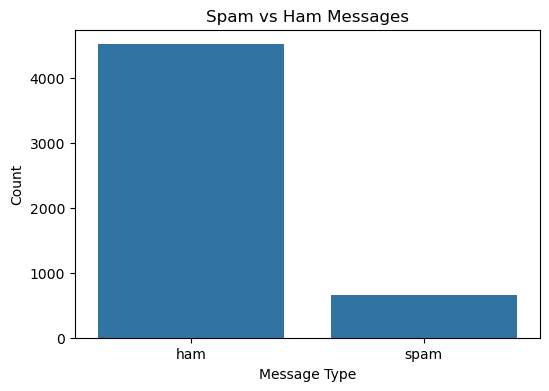

In [20]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="label")

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

In [21]:
df["message_length"] = df["message"].apply(len)

df.head()

,label,message,target,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",0,111
1,ham,Ok lar... Joking wif u oni...,0,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155
3,ham,U dun say so early hor... U c already then say...,0,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61


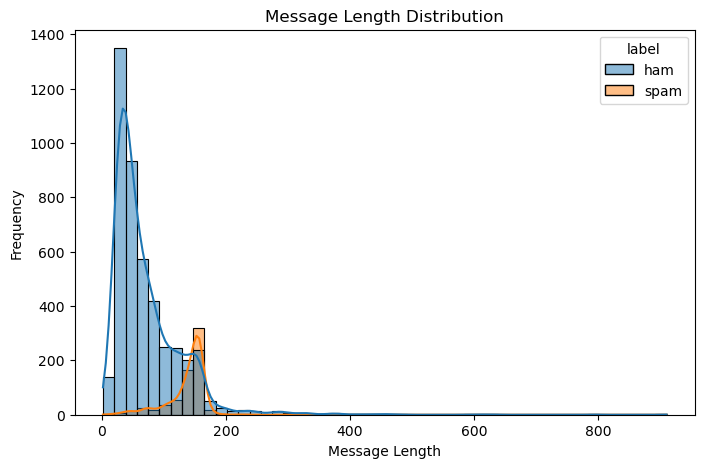

In [22]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()

In [23]:
X = df["message"]
y = df["target"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [25]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [26]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4135, 5000)
(1034, 5000)


In [27]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [29]:
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Logistic Regression
-------------------
Accuracy : 0.9564796905222437
Precision: 0.9777777777777777
Recall   : 0.6717557251908397
F1 Score : 0.7963800904977375


In [30]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.98       903
        Spam       0.98      0.67      0.80       131

    accuracy                           0.96      1034
   macro avg       0.97      0.83      0.89      1034
weighted avg       0.96      0.96      0.95      1034



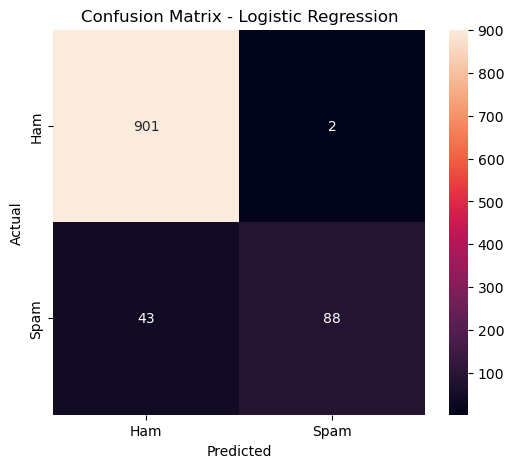

In [31]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [32]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

In [33]:
print("Naive Bayes")
print("-----------")

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))

Naive Bayes
-----------
Accuracy : 0.9709864603481625
Precision: 1.0
Recall   : 0.7709923664122137
F1 Score : 0.8706896551724138


In [34]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

In [35]:
print("Linear SVM")
print("----------")

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

Linear SVM
----------
Accuracy : 0.97678916827853
Precision: 0.9652173913043478
Recall   : 0.8473282442748091
F1 Score : 0.9024390243902439


In [37]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

print("Random Forest")
print("-------------")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest
-------------
Accuracy : 0.9748549323017408
Precision: 0.972972972972973
Recall   : 0.8244274809160306
F1 Score : 0.8925619834710744


In [38]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "Random Forest"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_rf)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.956480,0.977778,0.671756,0.796380
1,Naive Bayes,0.970986,1.000000,0.770992,0.870690
2,Linear SVM,0.976789,0.965217,0.847328,0.902439
3,Random Forest,0.974855,0.972973,0.824427,0.892562


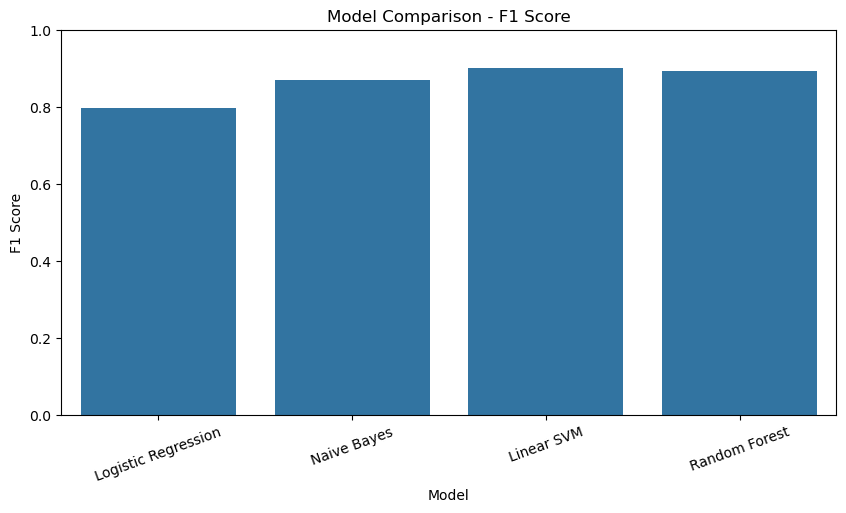

In [39]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="F1 Score"
)

plt.title("Model Comparison - F1 Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.show()

In [40]:
def predict_spam(message):
    
    message_tfidf = vectorizer.transform([message])
    
    prediction = svm_model.predict(message_tfidf)[0]
    
    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

In [41]:
message = "Congratulations! You won a free iPhone. Click now!"

print(predict_spam(message))

SPAM


In [42]:
message = "Hey, are you coming to college tomorrow?"

print(predict_spam(message))

HAM


In [43]:
messages = [
    "Congratulations! You won a free prize!",
    "Hey, what time are we meeting?",
    "URGENT! Claim your reward now!",
    "Can you send me the assignment?",
    "You have won 50000 dollars. Call now!"
]

for message in messages:
    print(message)
    print("Prediction:", predict_spam(message))
    print("-" * 60)

Congratulations! You won a free prize!
Prediction: SPAM
------------------------------------------------------------
Hey, what time are we meeting?
Prediction: HAM
------------------------------------------------------------
URGENT! Claim your reward now!
Prediction: SPAM
------------------------------------------------------------
Can you send me the assignment?
Prediction: HAM
------------------------------------------------------------
You have won 50000 dollars. Call now!
Prediction: HAM
------------------------------------------------------------


In [44]:
import os

os.makedirs("model", exist_ok=True)

joblib.dump(svm_model, "model/spam_model.pkl")
joblib.dump(vectorizer, "model/tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!


In [45]:
model = joblib.load("model/spam_model.pkl")

vectorizer = joblib.load(
    "model/tfidf_vectorizer.pkl"
)

In [ ]:
message = "Congratulations! You won a free car!"

message_tfidf = vectorizer.transform([message])

prediction = model.predict(message_tfidf)

if prediction[0] == 1:
    print("SPAM")
else:
    print("HAM")